<a href="https://colab.research.google.com/github/KushagraPan/machine-learning-zoomcamp/blob/main/Homework2_zoomcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"



In [7]:
df= pd.read_csv(data)
df.head(5)

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  object 
 2   fuel_type            10000 non-null  object 
 3   drivetrain           10000 non-null  object 
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), object(3)
memory usage: 859.5+ KB


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

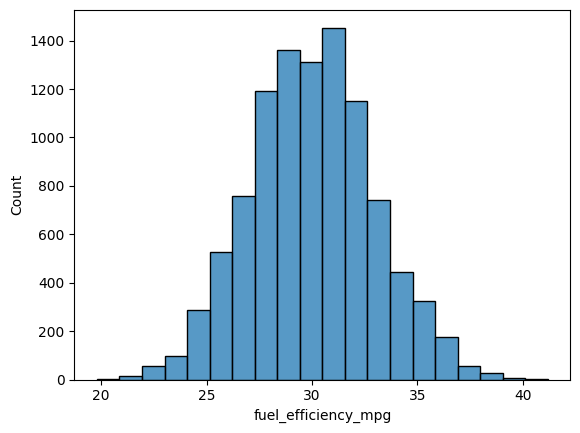

In [25]:
sns.histplot(df.fuel_efficiency_mpg,bins=20)


**No, fuel_efficiency_mpg does not have a long tail.**

In [26]:
df = df[
    [
        'engine_displacement',
        'horsepower',
        'vehicle_weight',
        'model_year',
        'fuel_efficiency_mpg'
    ]
]

In [27]:
df.isnull().sum()

,0
engine_displacement,0
horsepower,877
vehicle_weight,0
model_year,0
fuel_efficiency_mpg,0


In [18]:
median_hp = df.horsepower.median()
median_hp

254.0

In [29]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [30]:
n , n_val, n_test, n_train


(10000, 2000, 2000, 6000)

In [31]:
np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)
idx

array([6252, 4684, 1731, ..., 5390,  860, 7270])

In [32]:
df_train = df.iloc[idx[:n_train]]
print(idx[:n_train])
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

[6252 4684 1731 ... 7288  278 3252]


In [33]:
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

In [37]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)




In [38]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']



In [40]:
def train_linear_regression(X, y):
  ones = np.ones(X.shape[0])
  X = np.column_stack([ones, X])
  XTX = X.T.dot(X)
  XTX_inv = np.linalg.inv(XTX)
  w_full = XTX_inv.dot(X.T).dot(y)
  return w_full[0], w_full[1:]

In [41]:
X_train = df_train.fillna(0)
X_val = df_val.fillna(0)

w0, w = train_linear_regression(X_train.values, y_train)

y_pred = w0 + X_val.dot(w)

rmse_zero = np.sqrt(np.mean((y_pred - y_val) ** 2))

round(rmse_zero, 3)

np.float64(2.205)

In [42]:
mean_hp = df_train.horsepower.mean()
mean_hp

np.float64(254.46338337605272)

In [43]:
X_train = df_train.fillna(mean_hp)
X_val = df_val.fillna(mean_hp)

In [44]:
w0, w = train_linear_regression(X_train.values, y_train)
y_pred = w0 + X_val.dot(w)
rmse_mean = np.sqrt(np.mean((y_pred - y_val) ** 2))
round(rmse_mean, 3)

np.float64(2.202)

In [47]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [46]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [49]:
X_train = df_train.fillna(0)
X_val = df_val.fillna(0)

In [52]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    y_pred = w0 + X_val.dot(w)

    print(f'r is {r} , w0 is {w0} ',  round(rmse(y_val, y_pred),4))

r is 0 , w0 is -153.8849618823138  2.2053
r is 0.01 , w0 is -148.3092124404723  2.2058
r is 0.1 , w0 is -111.83871039306318  2.2241
r is 1 , w0 is -32.331865964971264  2.3492
r is 5 , w0 is -7.7728522099734025  2.4094
r is 10 , w0 is -3.9871164160193766  2.4195
r is 100 , w0 is -0.40821964884790385  2.4292


In [60]:
rmse_scores = []

for seed in range(10):

    # Split the data
    np.random.seed(seed)

    idx = np.arange(len(df))
    np.random.shuffle(idx)

    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    X_train = df_train.fillna(0)
    X_val = df_val.fillna(0)


    w0, w = train_linear_regression(
        X_train.values,
        y_train
    )


    y_pred = w0 + X_val.dot(w)

    # RMSE
    score = rmse(y_val, y_pred)
    rmse_scores.append(score)

    print(seed, score)

0 2.239204143046126
1 2.2021128210838845
2 2.1634197787530947
3 2.2043588768539224
4 2.2018800943311554
5 2.2457851509085134
6 2.2697212079524043
7 2.190794599933443
8 2.216611201686444
9 2.2070365928178957


In [64]:
    round(np.std(rmse_scores), 3)

np.float64(0.029)

In [67]:
np.random.seed(9)

idx = np.arange(len(df))
np.random.shuffle(idx)

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [68]:
df_train_full = pd.concat([df_train, df_val])

In [70]:
y_train_full = df_train_full.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train_full['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [72]:
X_train_full = df_train_full.fillna(0)
X_test = df_test.fillna(0)

In [73]:
w0, w = train_linear_regression_reg(
    X_train_full.values,
    y_train_full,
    r=0.001
)

In [75]:
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)

round(score, 3)

np.float64(2.236)